![lop](../../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    FCH4 vs. USTAR
</b>
</span>

---
**Notebook version**: `1` (19 Nov 2023)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Background
- This notebook investigates the eddy covariance CH4 flux (nmol m-2 s-1) in relation to USTAR (m s-1).
- The used dataset is a special version of the [FLUXNET-CH4 Community Product](https://fluxnet.org/data/fluxnet-ch4-community-product/).
- `FCH4` in this notebook is the flux **before** USTAR filtering.

# Setup

In [13]:
# Variable names in data files
USTAR1 = 'USTAR'
FLUX1 = 'FCH4_L3.1_L3.2_QCF0'

# Source folder with data files in parquet format
SOURCEDIR = r"data/CH4/OBriner"

# Imports

In [14]:
import importlib.metadata
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd

from diive.core.io.filereader import search_files
from diive.core.io.files import load_parquet
from diive.core.plotting.scatter import ScatterXY

version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.71.0


# Search data files
- All data files were first converted to the [Parquet](https://parquet.apache.org/) format for faster processing.

In [15]:
foundfiles = search_files(searchdirs=[SOURCEDIR], pattern='*.parquet')
# foundfiles = foundfiles[0:11]
[print(f"{ix}: {f}") for ix, f in enumerate(foundfiles)];

0: data\CH4\OBriner\OB_2022-2023_FN2O_Level3.2.parquet


# Create plots (with bins)

Patch 1 (0-12)
Loaded .parquet file data\CH4\OBriner\OB_2022-2023_FN2O_Level3.2.parquet (0.077 seconds). Detected time resolution of <30 * Minutes> / 30T 


L:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\scatter.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.xy_df_binned = self.xy_df.groupby(groupcol).agg({'mean', 'median', 'std', 'count', q25, q75})


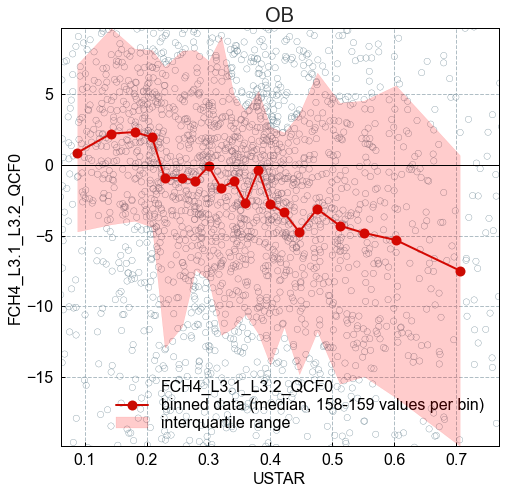

In [16]:
patch = 0
for firstfile in range(0, n_files, 12):    
    patch += 1
    lastfile = firstfile + 12
    print(f"Patch {patch} ({firstfile}-{lastfile})")
    plot(foundfiles=foundfiles[firstfile:lastfile], patchid=patch)    

In [18]:
df = load_parquet(foundfiles[0])

Loaded .parquet file data\CH4\OBriner\OB_2022-2023_FN2O_Level3.2.parquet (0.066 seconds). Detected time resolution of <30 * Minutes> / 30T 


In [20]:
df['USTAR'].describe()

count    10618.000000
mean         0.317457
std          0.193088
min          0.012559
25%          0.179652
50%          0.296886
75%          0.421914
max          3.243290
Name: USTAR, dtype: float64